# VAR — WTI Crude Oil Next-Day Direction Classification

## Overview

This notebook uses a **Vector Autoregression (VAR)** model to classify the next-day price direction of WTI crude oil as **Up (+1)** or **Down (−1)**.

| Design decision | Detail |
|---|---|
| **Model** | VAR(p) — joint linear model over WTI log-return + 31 FRED-MD macro variables |
| **Endogenous system** | Stationary matrix Z ∈ ℝ^{T×32}: WTI log-return (col 0) + 31 t-code-transformed macro series |
| **Lag order** | p ∈ {1…5}, selected by 5-fold TimeSeriesSplit CV (directional accuracy) |
| **Classification** | sign(forecast WTI log-return) > threshold → Up (+1), else Down (−1) |
| **Threshold** | Tuned on validation set by balanced accuracy; default θ = 0 |
| **predict_proba** | P(Up) = Φ((forecast − θ) / σ), σ from training forecasts only |
| **Class imbalance** | VAR is OLS — no loss reweighting. Sole mitigation: threshold tuning on val |
| **Leakage controls** | Monthly macro shifted +1 month; forward-filled to trading days; 1-step sequential forecasting uses only actual past observations |

In [76]:
# ============================================================
# Imports
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import time
from abc import ABC, abstractmethod
from scipy.stats import norm

from statsmodels.tsa.vector_ar.var_model import VAR

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    balanced_accuracy_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

## 2. Abstract Base Class

In [77]:
# ============================================================
# Abstract base class shared by all models (EN, XGB, VAR, LSTM)
# ============================================================
class BaseForecastModel(ABC):
    def __init__(self, task_type: str):
        self.task_type = task_type  # "classification" for this notebook

    @abstractmethod
    def fit(self, *args, **kwargs): pass

    @abstractmethod
    def predict(self, *args, **kwargs): pass

    @abstractmethod
    def evaluate(self, *args, **kwargs): pass

    @abstractmethod
    def save(self, filepath: str): pass

    @abstractmethod
    def load(self, filepath: str): pass

## 3. Classification Evaluation Metrics

In [78]:
# ============================================================
# Classification Evaluation Metrics
# ============================================================
def evaluate_classification(y_true, y_pred, y_prob=None, label=""):
    """
    Compute and print a full classification report.
    Returns a dict of scalar metrics for downstream use.

    Args:
        y_true : array of true labels (+1 / -1)
        y_pred : array of predicted labels (+1 / -1)
        y_prob : predicted probabilities for class +1 (optional, for ROC-AUC)
        label  : string label printed in the header
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=None, labels=[-1, 1])
    rec  = recall_score(y_true, y_pred, average=None, labels=[-1, 1])
    f1   = f1_score(y_true, y_pred, average=None, labels=[-1, 1])
    f1_w = f1_score(y_true, y_pred, average='weighted')
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan

    if label:
        print(f"\n{'─'*50}")
        print(f"  {label}")
        print(f"{'─'*50}")
    print(classification_report(y_true, y_pred, target_names=["Down (-1)", "Up (+1)"]))
    print(f"  ROC-AUC : {auc:.4f}")
    print(f"  F1 (wtd): {f1_w:.4f}")

    return {
        "accuracy":    acc,
        "prec_down":   prec[0], "prec_up":   prec[1],
        "rec_down":    rec[0],  "rec_up":    rec[1],
        "f1_down":     f1[0],   "f1_up":     f1[1],
        "f1_weighted": f1_w,
        "roc_auc":     auc,
    }

## 4. FRED-MD T-Code Stationarity Transformations

In [79]:
# ============================================================
# FRED-MD T-Code Stationarity Transformations
# ============================================================

# Official transformation codes for the 31 selected variables.
# Source: FRED-MD appendix (McCracken & Ng, 2016).
TCODE_MAP = {
    # T-code 5 — log first difference (growth rate)
    "RPI":        5, "W875RX1":    5, "CMRMTSPLx":  5,
    "IPFPNSS":    5, "USWTRADE":   5, "USTRADE":     5,
    "BUSLOANS":   5, "CONSPI":     5, "S&P 500":     5,
    "EXSZUSx":    5, "EXJPUSx":    5, "EXUSUKx":     5,
    "EXCAUSx":    5, "PPICMM":     5,
    # T-code 2 — first difference
    "FEDFUNDS":   2, "TB3MS":      2, "TB6MS":       2,
    "GS1":        2, "GS5":        2, "GS10":        2,
    "AAA":        2, "BAA":        2, "TB3SMFFM":    2,
    "TB6SMFFM":   2, "T1YFFM":     2, "T5YFFM":      2,
    "T10YFFM":    2, "AAAFFM":     2, "BAAFFM":      2,
    # T-code 1 — level (no transformation needed)
    "S&P PE ratio": 1, "UMCSENTx": 1,
}


def apply_tcodes(df: pd.DataFrame, tcode_map: dict) -> pd.DataFrame:
    """
    Apply FRED-MD stationarity transformations column-by-column.

    T-code 1 : x_t                      (level, no change)
    T-code 2 : x_t - x_{t-1}            (first difference)
    T-code 5 : ln(x_t) - ln(x_{t-1})   (log first difference / growth rate)
    """
    out = pd.DataFrame(index=df.index)
    for col in df.columns:
        tc = tcode_map.get(col, 1)
        x = df[col].astype(float)
        if tc == 1:
            out[col] = x
        elif tc == 2:
            out[col] = x.diff()
        elif tc == 5:
            out[col] = np.log(x).diff()
        else:
            out[col] = x.diff()
    return out

## 5. Data Helpers

**Leakage controls:**
- Monthly FRED-MD is shifted forward by one month before forward-filling to trading days. At prediction time t, only the *previous* month's macro release is visible.
- The WTI log-return (endogenous series) is the first-difference of log prices — stationary by construction.
- Note: VAR uses the raw stationary time-series matrix directly. No hand-crafted lags are needed; VAR constructs its own lag structure internally up to order p.

In [80]:
# ============================================================
# Data Helpers — leakage-safe, trading-day aligned
# ============================================================

def load_macro_monthly(path: Path, features: list) -> pd.DataFrame:
    """Load FRED-MD CSV, skip the metadata row, keep only the 31 selected features."""
    df = pd.read_csv(path, skiprows=[1]).rename(columns={"sasdate": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    keep = [c for c in features if c in df.columns]
    missing = [c for c in features if c not in df.columns]
    if missing:
        print(f"[WARN] Missing macro columns (skipped): {missing}")
    return df[keep].copy()


def load_price(path: Path) -> pd.Series:
    """Load WTI daily closing prices from Investing.com CSV format."""
    px = pd.read_csv(path, parse_dates=["Date"])
    return px.set_index("Date")["Price"].sort_index()


def make_log_return(price: pd.Series) -> pd.Series:
    """
    Compute WTI daily log-return: ret_t = ln(P_t) - ln(P_{t-1}).
    This is the endogenous WTI series entered into the VAR — stationary by construction.
    """
    return np.log(price.astype(float)).diff().rename("wti_ret")


def make_direction_target(price: pd.Series) -> pd.Series:
    """
    Binary next-day direction label.
      +1  if Price[t] > Price[t-1]  (Up)
      -1  if Price[t] <= Price[t-1] (Down / flat)
    """
    price = price.astype(float)
    direction = np.sign(price.diff())
    direction[direction == 0] = -1
    return direction.rename("y")

## 6. VAR Dataset Builder

Unlike the other notebooks, `build_var_dataset` returns a stationary **time-series matrix** Z ∈ ℝ^{T×32} rather than a lagged feature matrix. VAR(p) constructs its own internal lags up to order p, so we provide the raw stationary observations.

- Column 0: WTI log-return (endogenous target series)
- Columns 1–31: t-code-transformed FRED-MD variables
- One-month macro shift applied before forward-filling (same anti-leakage rule as all other notebooks)

In [81]:
# ============================================================
# VAR Dataset Builder
# ============================================================

def build_var_dataset(
    macro_file: Path,
    price_file: Path,
    features: list,
    train_end: str = "2014-12-31",
    val_end:   str = "2024-12-31",
):
    """
    Build leakage-safe train/val/test stationary time-series matrices for VAR.

    Returns
    -------
    Z_train, y_train, Z_val, y_val, Z_test, y_test : pd.DataFrame / pd.Series
        Z_* : stationary endogenous matrix (T × 32); WTI log-return in column 0
        y_* : binary direction labels in {-1, +1}
    wti_col : int — column index of WTI log-return in Z (always 0)
    """
    # 1. Load and t-code-transform macro (monthly)
    macro_m = load_macro_monthly(macro_file, features)
    macro_m = apply_tcodes(macro_m, TCODE_MAP)

    # Shift index forward by one month: day t sees the *previous* month's release.
    # E.g. January macro values become available on February 1st.
    macro_m.index = macro_m.index + pd.offsets.MonthBegin(1)

    # 2. Load price; compute WTI log-return (stationary endogenous variable)
    price   = load_price(price_file)
    wti_ret = make_log_return(price)          # NaN at first row

    # 3. Forward-fill monthly macro to trading days
    macro_d = macro_m.reindex(price.index, method="ffill")

    # 4. Assemble endogenous matrix: WTI log-return first, then macro
    Z = pd.concat([wti_ret, macro_d], axis=1).dropna()
    wti_col = 0  # WTI log-return is always column 0

    # 5. Build binary direction target (next-day sign of WTI price change)
    y = make_direction_target(price).reindex(Z.index).dropna()
    Z = Z.loc[y.index]

    # 6. Chronological split — no shuffling
    tr = Z.index <= pd.Timestamp(train_end)
    va = (Z.index > pd.Timestamp(train_end)) & (Z.index <= pd.Timestamp(val_end))
    te = Z.index > pd.Timestamp(val_end)

    print(f"VAR dataset — Train: {tr.sum()}  Val: {va.sum()}  Test: {te.sum()}")
    print(f"Endogenous matrix shape: {Z.shape}  (cols: WTI + {len(features)} macro)")
    print(f"Class balance — Up={(y==1).sum()}  Down={(y==-1).sum()}")

    return (
        Z.loc[tr], y.loc[tr],
        Z.loc[va], y.loc[va],
        Z.loc[te], y.loc[te],
        wti_col,
    )

## 7. Naive Majority-Class Baseline

In [82]:
# ============================================================
# Naive Majority-Class Baseline
# ============================================================

def naive_baseline_metrics(y_train, y_eval):
    """Predict the majority class from y_train for every observation in y_eval."""
    majority = 1 if (y_train == 1).sum() >= (y_train == -1).sum() else -1
    y_pred = np.full(len(y_eval), majority)
    print(f"  Naive baseline always predicts: {'Up (+1)' if majority == 1 else 'Down (-1)'}")
    return evaluate_classification(y_eval, y_pred, y_prob=None, label="Naive Baseline")

## 8. VAR Direction Classifier

### Model
VAR(p) models each variable at time t as a linear function of p lags of all variables:

$$Z_t = c + A_1 Z_{t-1} + \cdots + A_p Z_{t-p} + \varepsilon_t$$

where $Z_t \in \mathbb{R}^{k}$, $A_i \in \mathbb{R}^{k\times k}$, and $\varepsilon_t$ is white noise. Each equation is estimated by OLS.

### Feature Selection
With 31 FRED-MD candidates, an unrestricted VAR is massively overparameterised. **Greedy forward selection using WTI-equation-specific AIC** (max 5 features, training data only) shrinks the endogenous system by selecting only features that reduce WTI return prediction error:

$$\text{AIC}_{WTI}(p) = n \ln\!\left(\frac{RSS}{n}\right) + 2k$$

where RSS is from the OLS regression of $\text{wti\_ret}$ on its own lags and candidate lags at order $p$. AIC (penalty $2k$) is preferred over BIC (penalty $k\ln n \approx 7k$ for $n=1200$) for forecasting tasks: BIC is too conservative and selects only 1 feature on near-white-noise daily returns. AIC still penalises complexity but allows features through when they provide genuine marginal predictive value for WTI.

### Lag Order Selection
After feature selection, $p \in \{1,\ldots,5\}$ is chosen by **system BIC on the reduced VAR**.

### 1-Step Sequential Forecasting (no leakage)
The final VAR is fit **once** on the reduced `Z_train`. For each step `i` in val/test:
- Pass the actual last-p observed rows as history
- `results.forecast(y=window, steps=1)` → forecast vector
- Extract column 0 (WTI log-return): $\hat{y}_{ret}$

This strictly uses actual historical data — no feedback of model outputs into the history window.

### Classification
- **Default:** $\hat{y}_{ret} > 0 \Rightarrow$ Up (+1), else Down (−1)
- **Threshold tuning:** search $\theta \in [-0.005, +0.005]$ on validation set by balanced accuracy
- **Final:** $\hat{y}_{ret} > \theta \Rightarrow$ Up (+1)

### predict_proba (for ROC-AUC)
$$P(\text{Up}) = \Phi\!\left(\frac{\hat{y}_{ret} - \theta}{\sigma}\right)$$
where $\sigma$ = std of training rolling forecasts (estimated during `fit()` — no leakage).

### Class Imbalance
VAR is estimated by OLS — there is no classification loss function to reweight. Imbalance is addressed via **threshold tuning on the validation set** using balanced accuracy as the objective, which directly targets the average of Down and Up recall.

In [83]:
# ============================================================
# 8a. WTI-Equation BIC helper + Greedy Feature Selection
# ============================================================
def wti_ols_aic(Z_train, target_col, feature_cols, p):
    """
    AIC of the OLS regression:
        wti_ret_t ~ const + lags(wti_ret, 1..p) + lags(feature_cols, 1..p)

    AIC (penalty=2k) is preferred over BIC (penalty=k*log(n)) for forecasting:
    BIC is too conservative for near-white-noise daily returns and stops after
    selecting 1 feature. AIC allows more features through when they provide
    marginal predictive gain for WTI.
    """
    frames = []
    for col in [target_col] + list(feature_cols):
        for lag in range(1, p + 1):
            frames.append(Z_train[col].shift(lag).rename(f'{col}_L{lag}'))
    X = pd.concat(frames, axis=1).dropna().values
    y = Z_train[target_col].iloc[p:].values
    X_des = np.c_[np.ones(len(X)), X]               # prepend intercept column
    coef, _, _, _ = np.linalg.lstsq(X_des, y, rcond=None)
    rss  = ((y - X_des @ coef) ** 2).sum()
    n, k = len(y), X_des.shape[1]
    return n * np.log(rss / n) + 2 * k               # AIC


def greedy_var_feature_select(Z_train, target_col, candidate_cols,
                               max_features=5, max_lag=5):
    """
    Forward-stepwise feature selection using WTI-equation-specific AIC.

    For each candidate, computes min AIC over lag orders p in {1..max_lag}
    for the OLS regression of wti_ret on its own lags + candidate lags.
    AIC (penalty=2k) is used instead of BIC because BIC is too conservative
    for near-white-noise daily returns — it stops after 1 feature. AIC still
    penalises complexity but allows features through when they provide
    genuine marginal predictive value for WTI.

    Returns (selected_features, bic_curve) where bic_curve[i] is the
    best WTI-equation BIC after adding the i-th feature.
    """
    selected  = []
    bic_curve = []
    remaining = [c for c in candidate_cols if c in Z_train.columns]
    best_global_bic = np.inf

    for _ in range(max_features):
        best_bic  = np.inf
        best_feat = None
        for feat in remaining:
            try:
                # Best AIC over lag orders for WTI equation with this feature
                bic = min(
                    wti_ols_aic(Z_train, target_col, selected + [feat], p)
                    for p in range(1, max_lag + 1)
                )
                if bic < best_bic:
                    best_bic  = bic
                    best_feat = feat
            except Exception:
                continue
        if best_feat is None or best_bic >= best_global_bic:
            break
        selected.append(best_feat)
        bic_curve.append(best_bic)
        remaining.remove(best_feat)
        best_global_bic = best_bic

    print(f"  WTI-AIC greedy selected {len(selected)} features: {selected}")
    return selected, bic_curve


# ============================================================
# 8b. VAR Direction Classifier
# ============================================================
class VARDirectionClassifier(BaseForecastModel):
    """
    VAR(p) model for binary WTI price direction classification.

    Labels convention:
        External: +1 (Up) / -1 (Down)
        Classification: sign of 1-step-ahead WTI log-return forecast vs threshold

    Feature selection via greedy WTI-equation AIC (max 5 FRED-MD variables).
    Lag order selected by system BIC on the reduced endogenous system.
    predict_proba uses normal CDF scaling of the raw forecast for ROC-AUC.
    """

    def __init__(self, max_lag: int = 5, wti_col: int = 0):
        super().__init__("classification")
        self.max_lag  = max_lag
        self.wti_col  = wti_col

        self.model_              = None   # fitted VARResults
        self.best_p_             = None   # selected lag order
        self.selected_features_  = []     # macro columns chosen by WTI-BIC
        self.selection_bic_curve_= []     # WTI-equation BIC after each step
        self.bic_by_lag_         = {}     # {p: bic} on reduced system
        self.threshold_          = 0.0    # decision threshold in log-return space
        self.sigma_              = 1.0    # std of training forecasts (for CDF scaling)
        self.train_forecasts_    = None   # rolling 1-step forecasts on train (for ROC)

    # ── Internal: 1-step sequential forecast loop ─────────────────────────────
    @staticmethod
    def _sequential_forecast(var_results, Z_history, Z_future, p, wti_col):
        """
        Generate 1-step-ahead WTI log-return forecasts sequentially.
        No model outputs are fed back -- only actual observations.
        Returns array of shape (len(Z_future),).
        """
        Z_hist_vals = Z_history.values if hasattr(Z_history, 'values') else Z_history
        Z_fut_vals  = Z_future.values  if hasattr(Z_future,  'values') else Z_future
        Z_all  = np.vstack([Z_hist_vals, Z_fut_vals])
        n_hist = len(Z_hist_vals)
        forecasts = []
        for i in range(len(Z_fut_vals)):
            window = Z_all[n_hist + i - p : n_hist + i]
            fc = var_results.forecast(y=window, steps=1)
            forecasts.append(fc[0, wti_col])
        return np.array(forecasts)

    # ── Training ──────────────────────────────────────────────────────────────
    def fit(self, Z_train: pd.DataFrame, y_train: pd.Series):
        """
        1. Greedy WTI-equation AIC feature selection on Z_train (max 5 features).
        2. System BIC lag order selection on the reduced endogenous system.
        3. Fit final VAR(best_p) on reduced Z_train.
        4. Compute training-set rolling 1-step forecasts for sigma estimation.
        """
        # 1. Feature selection targeting WTI prediction (training data only)
        print("[VAR] Greedy WTI-equation AIC feature selection ...")
        candidate_cols = [c for c in Z_train.columns if c != "wti_ret"]
        self.selected_features_, self.selection_bic_curve_ = greedy_var_feature_select(
            Z_train, target_col="wti_ret",
            candidate_cols=candidate_cols,
            max_features=5, max_lag=self.max_lag,
        )

        # Reduced endogenous matrix: WTI + selected macro features
        cols  = ["wti_ret"] + self.selected_features_
        Z_red = Z_train[cols]

        # 2. System BIC lag selection on reduced system
        print(f"[VAR] BIC lag selection on {len(cols)}-variable system ...")
        best_bic, best_p = np.inf, 1
        for p in range(1, self.max_lag + 1):
            try:
                m = VAR(Z_red).fit(maxlags=p, ic=None, trend='c')
                self.bic_by_lag_[p] = m.bic
                print(f"  p={p}: BIC={m.bic:.2f}")
                if m.bic < best_bic:
                    best_bic, best_p = m.bic, p
            except Exception:
                continue
        self.best_p_ = best_p
        print(f"  -> Selected lag: p={self.best_p_}  (BIC={best_bic:.2f})")

        # 3. Final model on reduced system
        self.model_ = VAR(Z_red).fit(maxlags=self.best_p_, ic=None, trend='c')

        # 4. Training-set rolling forecasts (for sigma + ROC train curve)
        p     = self.best_p_
        Z_arr = Z_red.values
        train_fc = []
        for i in range(p, len(Z_red)):
            window = Z_arr[i - p : i]
            fc = self.model_.forecast(y=window, steps=1)
            train_fc.append(fc[0, 0])    # wti_ret is always col 0
        self.train_forecasts_ = np.array(train_fc)
        self.sigma_ = max(float(self.train_forecasts_.std()), 1e-8)

        return self

    # ── Inference ─────────────────────────────────────────────────────────────
    def _raw_forecasts(self, Z_history: pd.DataFrame,
                       Z_target: pd.DataFrame) -> np.ndarray:
        """1-step sequential WTI log-return forecasts over Z_target (reduced cols)."""
        cols = ["wti_ret"] + self.selected_features_
        return self._sequential_forecast(
            self.model_,
            Z_history[cols], Z_target[cols],
            self.best_p_, 0,    # wti_ret is always col 0 after slicing
        )

    def predict(self, Z_history: pd.DataFrame, Z_target: pd.DataFrame,
                threshold: float = None) -> np.ndarray:
        """Return predicted direction labels (+1 / -1)."""
        t  = threshold if threshold is not None else self.threshold_
        fc = self._raw_forecasts(Z_history, Z_target)
        return np.where(fc > t, 1, -1)

    def predict_proba(self, Z_history: pd.DataFrame,
                      Z_target: pd.DataFrame) -> np.ndarray:
        """Return P(Up) = Phi((forecast - theta) / sigma). Suitable for ROC-AUC."""
        fc = self._raw_forecasts(Z_history, Z_target)
        return norm.cdf((fc - self.threshold_) / self.sigma_)

    # ── Threshold tuning ──────────────────────────────────────────────────────
    def tune_threshold(self, Z_train: pd.DataFrame, Z_val: pd.DataFrame,
                       y_val: pd.Series, thresholds=None) -> float:
        """
        Search threshold in log-return space to maximise balanced accuracy on val.
        Balanced accuracy = (Down recall + Up recall) / 2.
        Updates self.threshold_ in-place.
        """
        if thresholds is None:
            thresholds = np.linspace(-0.005, 0.005, 101)
        fc = self._raw_forecasts(Z_train, Z_val)
        best_t, best_ba = 0.0, -np.inf
        for t in thresholds:
            pred = np.where(fc > t, 1, -1)
            ba   = balanced_accuracy_score(y_val.values, pred)
            if ba > best_ba:
                best_ba, best_t = ba, t
        self.threshold_ = best_t
        print(f"  Optimal threshold: {best_t:.5f}  "
              f"(val balanced accuracy: {best_ba:.4f})")
        return best_t

    # ── Evaluation ────────────────────────────────────────────────────────────
    def evaluate(self, Z_history, Z_target, y, label="", threshold=None):
        y_pred = self.predict(Z_history, Z_target, threshold=threshold)
        y_prob = self.predict_proba(Z_history, Z_target)
        return evaluate_classification(y.values, y_pred, y_prob, label=label)

    # ── Persistence ───────────────────────────────────────────────────────────
    def save(self, path: str):
        with open(path, "wb") as f:
            pickle.dump(self.__dict__, f)

    def load(self, path: str):
        with open(path, "rb") as f:
            self.__dict__.update(pickle.load(f))

## 9. Configuration

In [84]:
# ============================================================
# Configuration — edit paths here if needed
# ============================================================
MACRO_FILE = Path("../data/fred_md_2025_12.csv")
PRICE_FILE = Path("../data/price/Price.csv")

# 31 FRED-MD macro features (as specified in project requirements)
FEATURES = [
    "RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE", "USTRADE",
    "BUSLOANS", "CONSPI", "S&P 500", "S&P PE ratio", "FEDFUNDS",
    "TB3MS", "TB6MS", "GS1", "GS5", "GS10", "AAA", "BAA",
    "TB3SMFFM", "TB6SMFFM", "T1YFFM", "T5YFFM", "T10YFFM",
    "AAAFFM", "BAAFFM", "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx",
    "PPICMM", "UMCSENTx",
]

TRAIN_END = "2014-12-31"
VAL_END   = "2024-12-31"

## 10. Training

Run greedy BIC forward feature selection (up to 5 FRED-MD variables) on training data, then BIC-based lag selection on the reduced system, fit the final VAR(p\*) on all training data, tune the decision threshold on the validation set, and evaluate on both validation and test. All predictions are strictly out-of-sample via 1-step sequential forecasting.

In [85]:
# ============================================================
# Build dataset and train
# ============================================================
t0 = time.time()

Z_train, y_train, Z_val, y_val, Z_test, y_test, wti_col = build_var_dataset(
    MACRO_FILE, PRICE_FILE, FEATURES,
    train_end=TRAIN_END,
    val_end=VAL_END,
)

# ── Train VAR Direction Classifier ────────────────────────────────────────────
model = VARDirectionClassifier(max_lag=5, wti_col=wti_col)
model.fit(Z_train, y_train)

# ── Threshold tuning on validation set ────────────────────────────────────────
print("\n" + "="*60)
print("  THRESHOLD OPTIMISATION (tuned on val, applied to test)")
print("="*60)
Z_train_val = pd.concat([Z_train, Z_val])   # context for test-set forecasts
best_threshold = model.tune_threshold(Z_train, Z_val, y_val)

# ── Out-of-sample predictions ─────────────────────────────────────────────────
pred_val  = model.predict(Z_train,     Z_val,  threshold=best_threshold)
pred_test = model.predict(Z_train_val, Z_test, threshold=best_threshold)
prob_val  = model.predict_proba(Z_train,     Z_val)
prob_test = model.predict_proba(Z_train_val, Z_test)

# ── Evaluate ──────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  VAR — CLASSIFICATION RESULTS (tuned threshold)")
print("="*60)
val_metrics  = model.evaluate(Z_train,     Z_val,  y_val,  label="Validation")
test_metrics = model.evaluate(Z_train_val, Z_test, y_test, label="Test")

# ── Naive baseline ────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  NAIVE MAJORITY-CLASS BASELINE")
print("="*60)
naive_val  = naive_baseline_metrics(y_train, y_val.values)
naive_test = naive_baseline_metrics(y_train, y_test.values)

elapsed = time.time() - t0
print(f"\nTotal training time: {elapsed/60:.1f} min")

VAR dataset — Train: 7983  Val: 2635  Test: 216
Endogenous matrix shape: (10834, 32)  (cols: WTI + 31 macro)
Class balance — Up=5520  Down=5314
[VAR] Greedy WTI-equation AIC feature selection ...
  WTI-AIC greedy selected 4 features: ['USWTRADE', 'CMRMTSPLx', 'EXCAUSx', 'TB3MS']
[VAR] BIC lag selection on 5-variable system ...
  p=1: BIC=-51.92
  p=2: BIC=-51.90
  p=3: BIC=-51.87
  p=4: BIC=-51.85
  p=5: BIC=-51.83
  -> Selected lag: p=1  (BIC=-51.92)

  THRESHOLD OPTIMISATION (tuned on val, applied to test)
  Optimal threshold: 0.00040  (val balanced accuracy: 0.5191)

  VAR — CLASSIFICATION RESULTS (tuned threshold)

──────────────────────────────────────────────────
  Validation
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   Down (-1)       0.49      0.67      0.56      1240
     Up (+1)       0.56      0.37      0.45      1395

    accuracy                           0.51      2635
   macro avg       0.52      0.52      0

## 11. Summary Table — VAR vs Naive Baseline

In [86]:
# ============================================================
# Comparison Table — VAR vs Naive Baseline
# ============================================================
rows = []
for split, var_m, naive_m in [
    ("Validation", val_metrics,  naive_val),
    ("Test",       test_metrics, naive_test),
]:
    for name, m in [("VAR", var_m), ("Naive", naive_m)]:
        rows.append({
            "Split":     split,
            "Model":     name,
            "Accuracy":  f"{m['accuracy']:.4f}",
            "Prec Down": f"{m['prec_down']:.4f}",
            "Prec Up":   f"{m['prec_up']:.4f}",
            "Rec Down":  f"{m['rec_down']:.4f}",
            "Rec Up":    f"{m['rec_up']:.4f}",
            "F1 (wtd)":  f"{m['f1_weighted']:.4f}",
            "ROC-AUC":   f"{m['roc_auc']:.4f}" if not np.isnan(m['roc_auc']) else "N/A",
        })

print(pd.DataFrame(rows).to_string(index=False))
print(f"\nSelected lag order : p = {model.best_p_}")
print(f"Decision threshold : θ = {model.threshold_:.5f}")
print(f"Forecast std (σ)   :     {model.sigma_:.6f}")

     Split Model Accuracy Prec Down Prec Up Rec Down Rec Up F1 (wtd) ROC-AUC
Validation   VAR   0.5104    0.4853  0.5564   0.6669 0.3713   0.5002  0.5197
Validation Naive   0.5294    0.0000  0.5294   0.0000 1.0000   0.3665     N/A
      Test   VAR   0.4954    0.5000  0.4891   0.5688 0.4206   0.4926  0.5191
      Test Naive   0.4954    0.0000  0.4954   0.0000 1.0000   0.3282     N/A

Selected lag order : p = 1
Decision threshold : θ = 0.00040
Forecast std (σ)   :     0.001124


---
# Visualizations

## 12. Plot Setup

In [87]:
# ============================================================
# Plot Setup
# ============================================================
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'legend.fontsize': 10, 'figure.dpi': 150,
})
C_PALETTE = {
    'up':     '#2a9d8f',
    'down':   '#e76f51',
    'model':  '#57068c',   # NYU purple
    'naive':  '#a8a8a8',
    'accent': '#e63946',
}
print("Plot setup complete.")

Plot setup complete.


## 13. VAR Convergence — BIC vs Lag Order & Selected Features

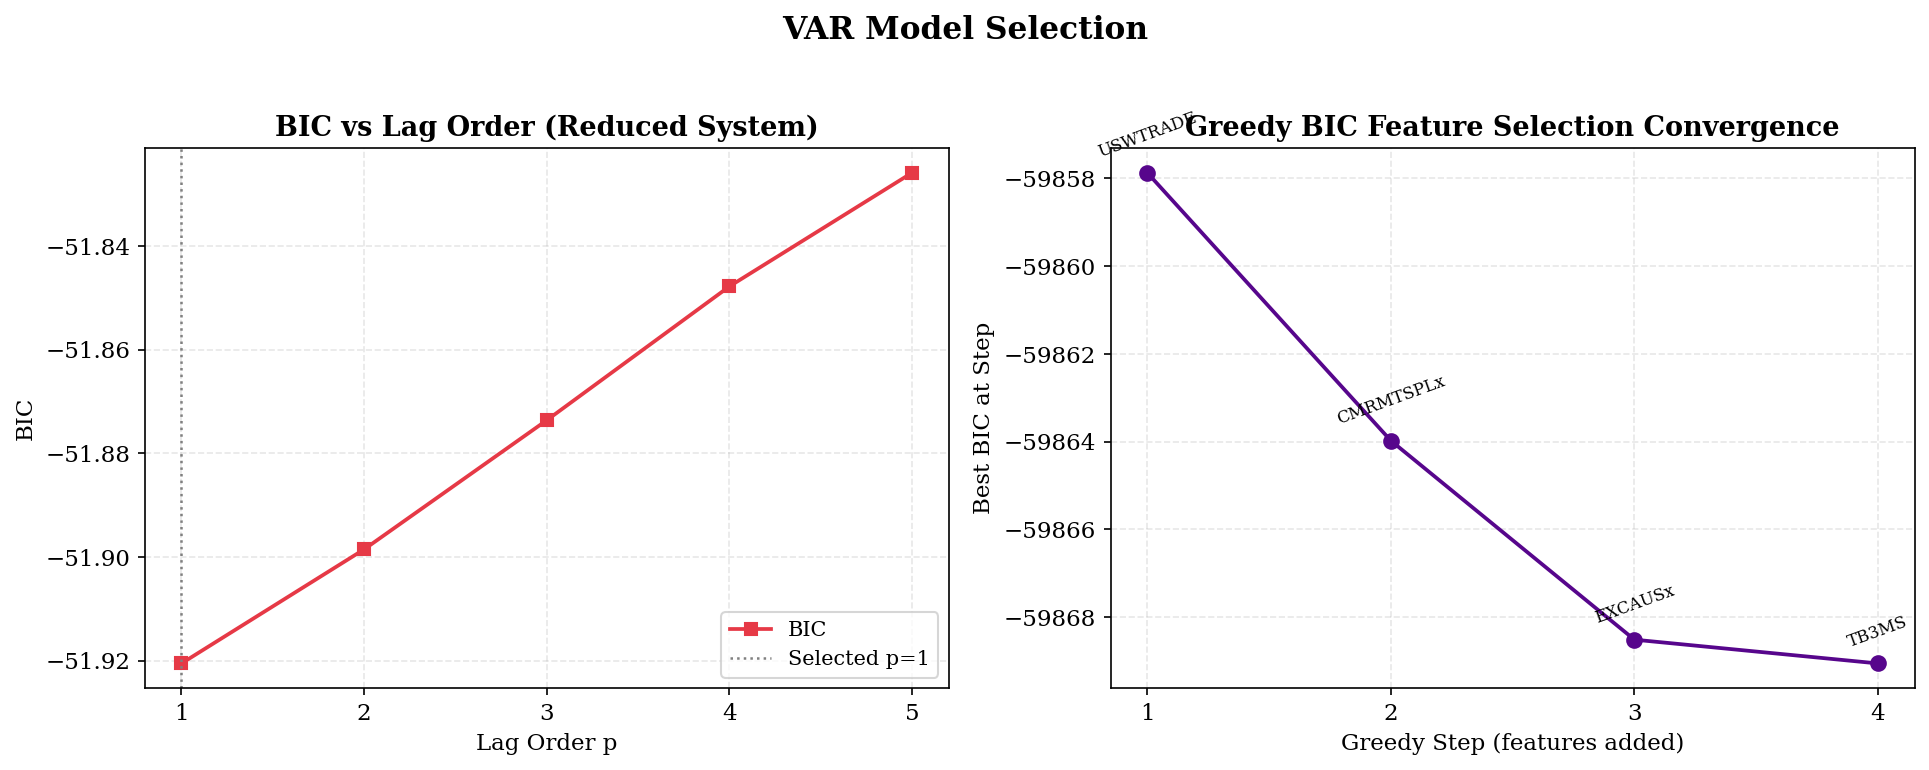

In [88]:
# ============================================================
# VAR Convergence -- BIC vs Lag Order  &  Greedy BIC Convergence
# ============================================================
p_vals   = list(model.bic_by_lag_.keys())
bic_vals = list(model.bic_by_lag_.values())

feats     = model.selected_features_
bic_curve = model.selection_bic_curve_
steps     = list(range(1, len(feats) + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Left: BIC vs lag order (reduced system) --
ax = axes[0]
ax.plot(p_vals, bic_vals, marker="s", color=C_PALETTE['accent'],
        lw=1.8, label="BIC")
ax.axvline(model.best_p_, color="gray", lw=1.2, ls=":",
           label=f"Selected p={model.best_p_}")
ax.set_xlabel("Lag Order p")
ax.set_ylabel("BIC")
ax.set_title("BIC vs Lag Order (Reduced System)", fontweight="bold")
ax.set_xticks(p_vals)
ax.legend()

# -- Right: greedy BIC convergence (BIC after each feature added) --
ax = axes[1]
ax.plot(steps, bic_curve, marker="o", color=C_PALETTE['model'],
        lw=1.8, ms=7)
for s, bic, feat in zip(steps, bic_curve, feats):
    ax.annotate(feat, xy=(s, bic), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=8,
                rotation=20)
ax.set_xlabel("Greedy Step (features added)")
ax.set_ylabel("Best BIC at Step")
ax.set_title("Greedy BIC Feature Selection Convergence", fontweight="bold")
ax.set_xticks(steps)

plt.suptitle("VAR Model Selection", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 14. Forecast Distribution

Histogram of the raw VAR 1-step-ahead WTI log-return forecasts on the validation and test sets. Bars are coloured by predicted class (green = Up, red = Down). The vertical dashed line marks the tuned decision threshold θ.

A narrow distribution clustered near zero is expected — linear VAR forecasts of a near-random-walk return series typically have low amplitude.

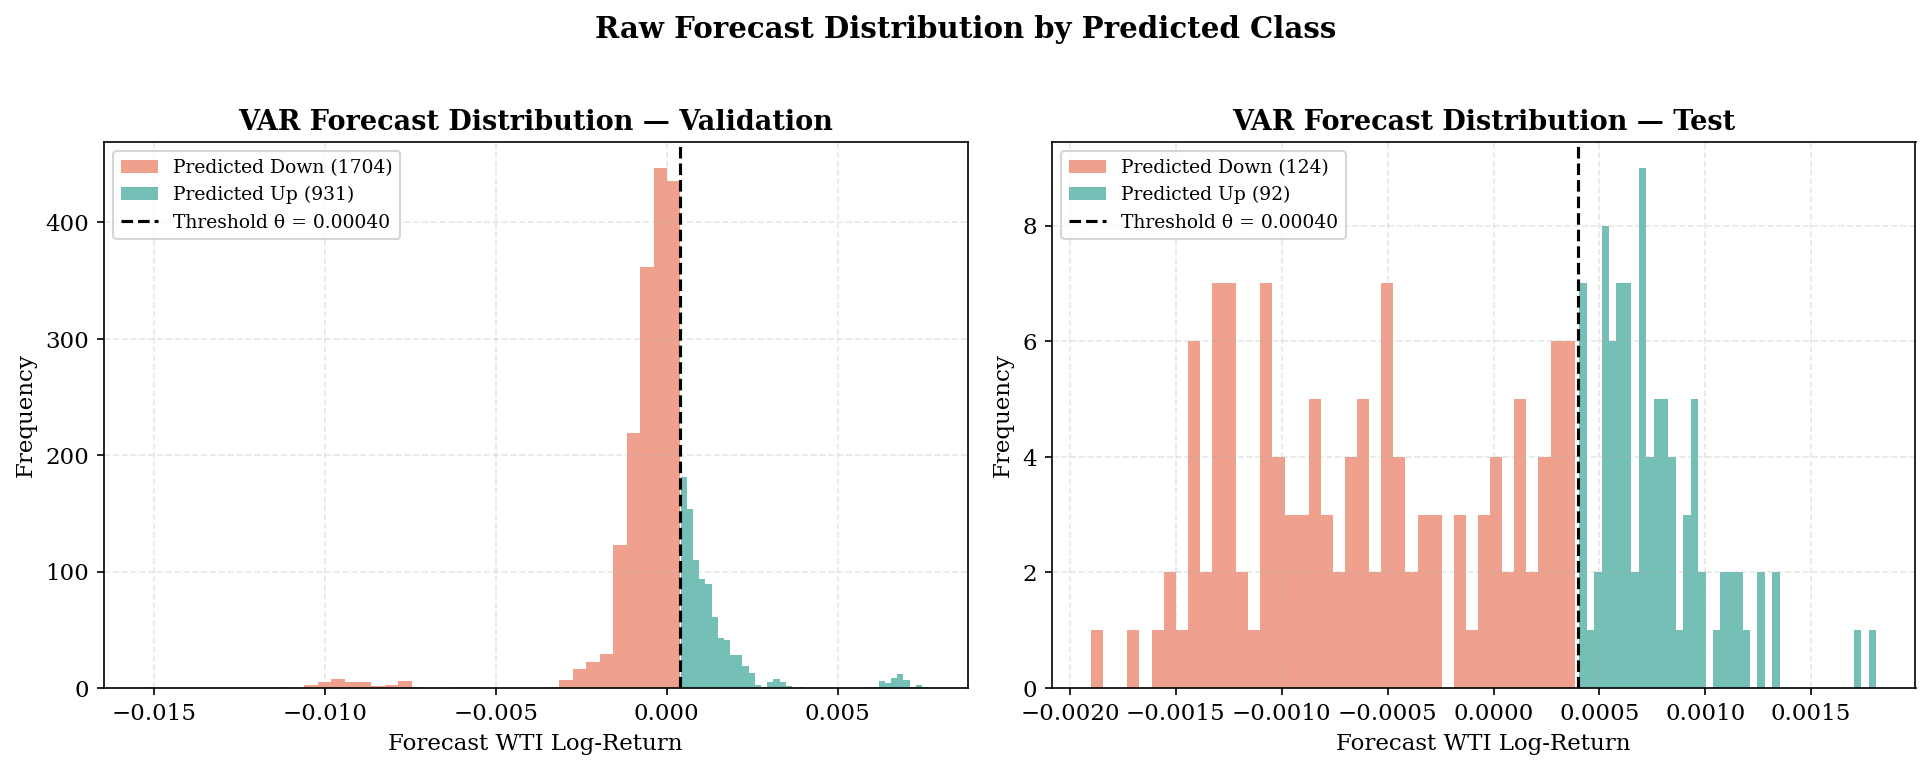

In [89]:
# ============================================================
# VAR Forecast Distribution — Val and Test
# ============================================================
fc_val  = model._raw_forecasts(Z_train,     Z_val)
fc_test = model._raw_forecasts(Z_train_val, Z_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, fc, title in [
    (axes[0], fc_val,  "Validation"),
    (axes[1], fc_test, "Test"),
]:
    up_mask   = fc > model.threshold_
    down_mask = ~up_mask

    ax.hist(fc[down_mask], bins=40, color=C_PALETTE['down'], alpha=0.65,
            label=f"Predicted Down ({down_mask.sum()})")
    ax.hist(fc[up_mask],   bins=40, color=C_PALETTE['up'],   alpha=0.65,
            label=f"Predicted Up ({up_mask.sum()})")
    ax.axvline(model.threshold_, color="black", lw=1.5, ls="--",
               label=f"Threshold θ = {model.threshold_:.5f}")
    ax.set_xlabel("Forecast WTI Log-Return")
    ax.set_ylabel("Frequency")
    ax.set_title(f"VAR Forecast Distribution — {title}", fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("Raw Forecast Distribution by Predicted Class",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 15. Confusion Matrices — Validation and Test

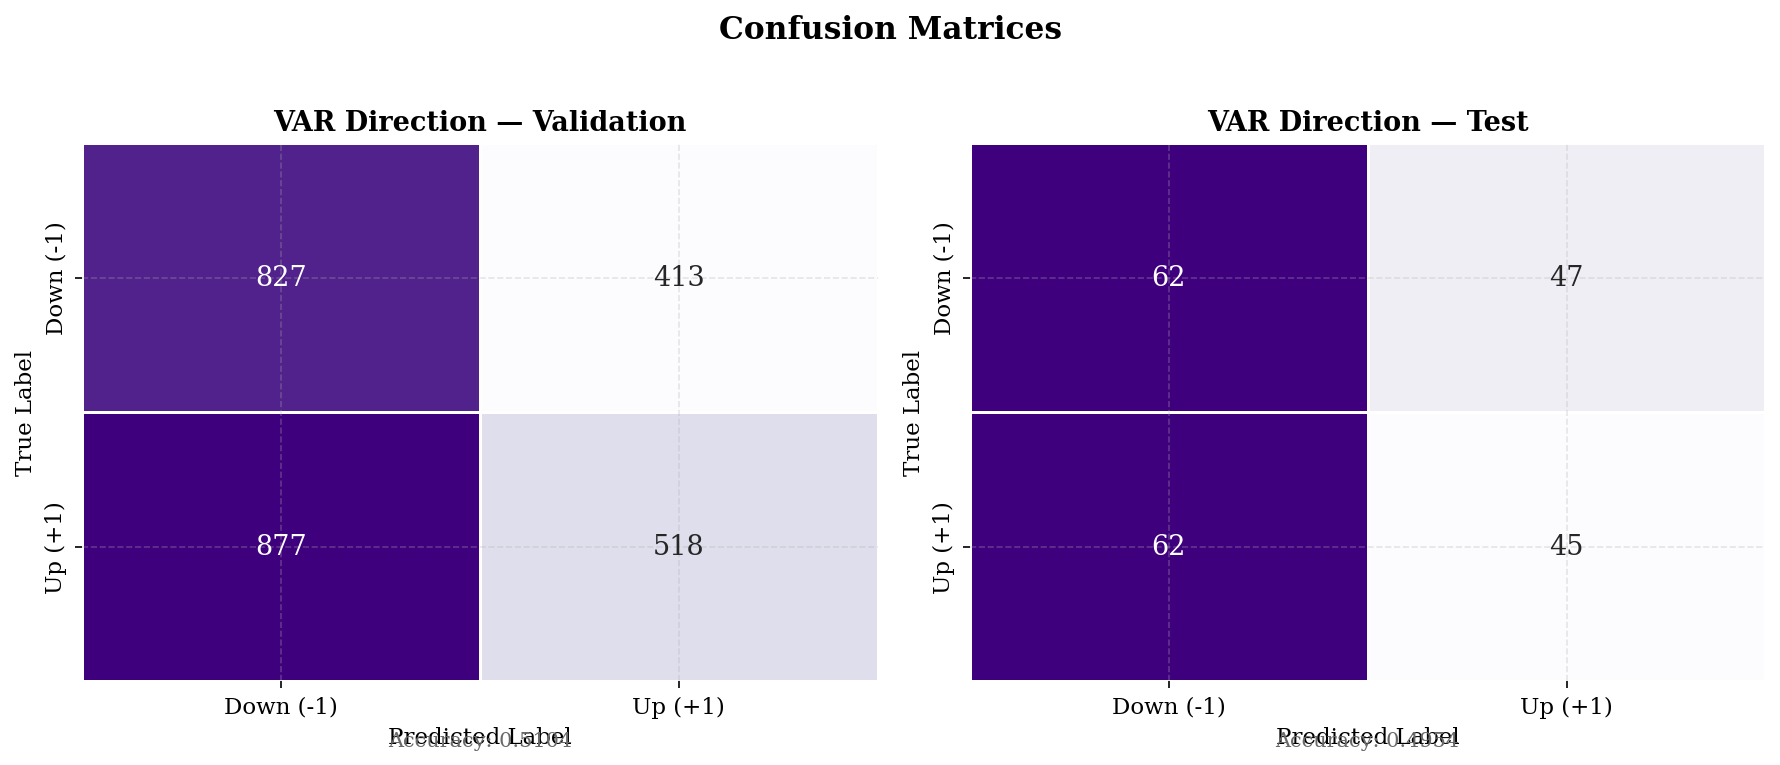

In [90]:
# ============================================================
# Confusion Matrix Heatmaps — Validation and Test
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ["Down (-1)", "Up (+1)"]

for ax, y_true, y_pred, title in [
    (axes[0], y_val.values,  pred_val,  "Validation"),
    (axes[1], y_test.values, pred_test, "Test"),
]:
    cm = confusion_matrix(y_true, y_pred, labels=[-1, 1])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Purples",
        xticklabels=labels, yticklabels=labels,
        linewidths=0.5, ax=ax, cbar=False,
        annot_kws={"size": 13},
    )
    ax.set_title(f"VAR Direction — {title}", fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    acc = accuracy_score(y_true, y_pred)
    ax.text(0.5, -0.12, f"Accuracy: {acc:.4f}", transform=ax.transAxes,
            ha="center", fontsize=10, color="dimgray")

plt.suptitle("Confusion Matrices", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 16. Rolling Accuracy Over Time (Test Set)

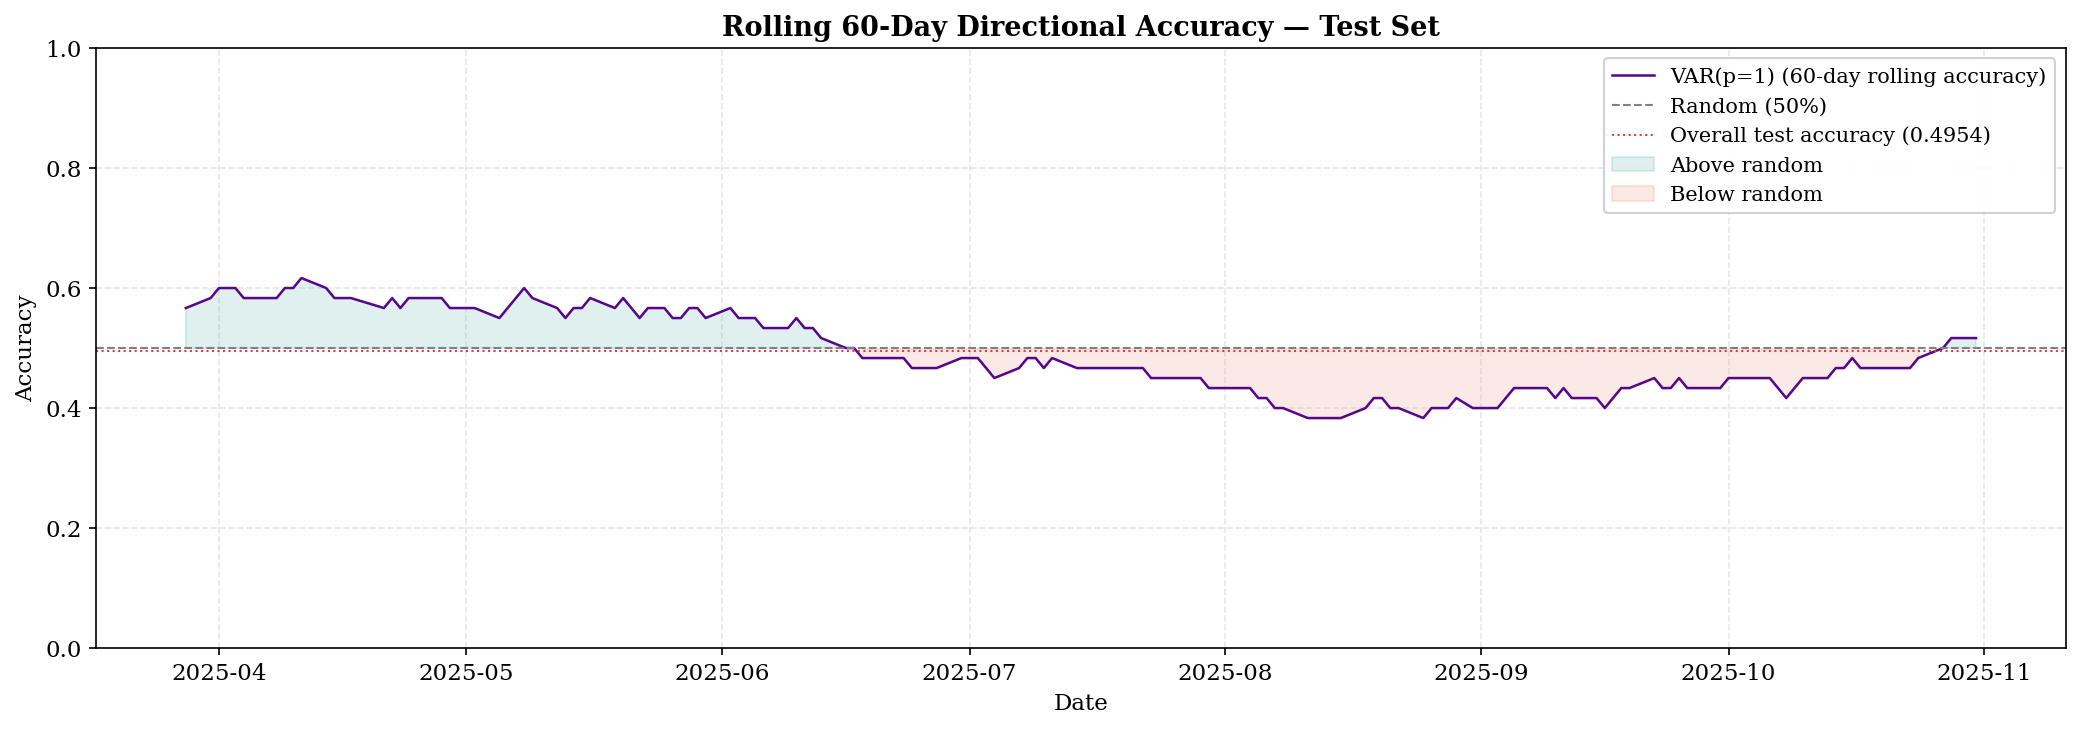

In [91]:
# ============================================================
# Rolling Accuracy Over Time (Test Set)
# ============================================================
roll_window = 60  # trading days

correct  = (pred_test == y_test.values).astype(int)
roll_acc = pd.Series(correct, index=y_test.index).rolling(roll_window).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(roll_acc.index, roll_acc.values, color=C_PALETTE['model'], lw=1.2,
        label=f"VAR(p={model.best_p_}) ({roll_window}-day rolling accuracy)")
ax.axhline(0.5, color="gray", lw=1, ls="--", label="Random (50%)")
ax.axhline(test_metrics["accuracy"], color=C_PALETTE['accent'], lw=1, ls=":",
           label=f"Overall test accuracy ({test_metrics['accuracy']:.4f})")
ax.fill_between(roll_acc.index, 0.5, roll_acc.values,
                where=roll_acc.values >= 0.5,
                alpha=0.15, color=C_PALETTE['up'], label="Above random")
ax.fill_between(roll_acc.index, 0.5, roll_acc.values,
                where=roll_acc.values < 0.5,
                alpha=0.15, color=C_PALETTE['down'], label="Below random")
ax.set_title(f"Rolling {roll_window}-Day Directional Accuracy — Test Set",
             fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Date")
ax.set_ylim(0, 1)
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

## 17. Predicted vs Actual Direction Distribution

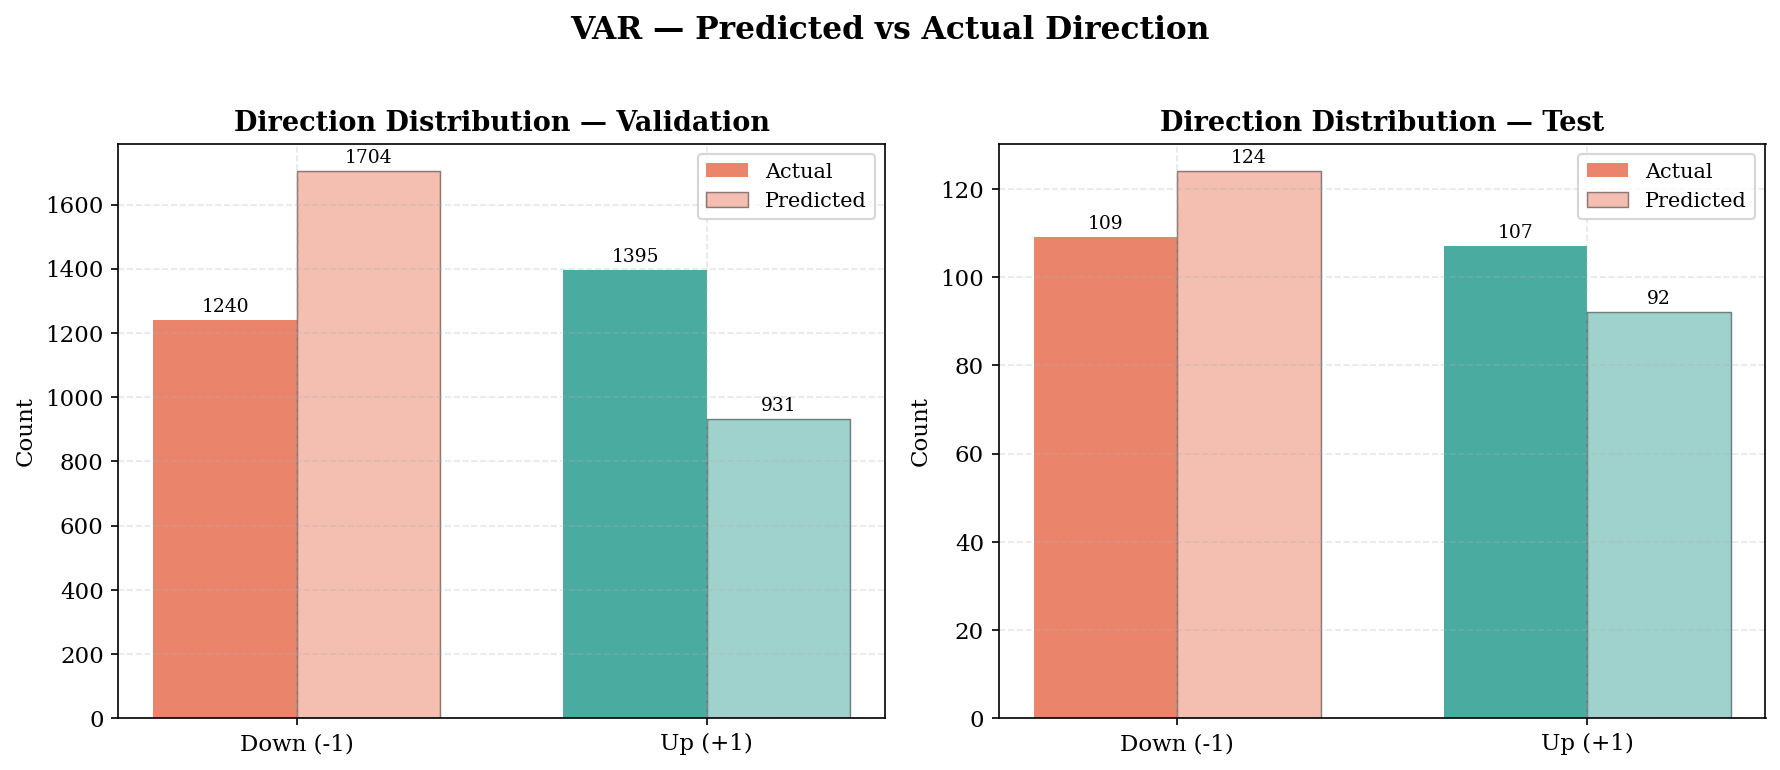

In [92]:
# ============================================================
# Predicted vs Actual Direction Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_val.values,  pred_val,  "Validation"),
    (axes[1], y_test.values, pred_test, "Test"),
]:
    cats = ["Down (-1)", "Up (+1)"]
    actual_counts = [(y_true == -1).sum(), (y_true == 1).sum()]
    pred_counts   = [(y_pred == -1).sum(), (y_pred == 1).sum()]

    x = np.arange(len(cats))
    w = 0.35
    b1 = ax.bar(x - w/2, actual_counts, w, label="Actual",
                color=[C_PALETTE['down'], C_PALETTE['up']], alpha=0.85)
    b2 = ax.bar(x + w/2, pred_counts,   w, label="Predicted",
                color=[C_PALETTE['down'], C_PALETTE['up']], alpha=0.45,
                edgecolor='black', linewidth=0.7)

    for bar in list(b1) + list(b2):
        ax.annotate(f"{int(bar.get_height())}",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=9)

    ax.set_title(f"Direction Distribution — {title}", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(cats)
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("VAR — Predicted vs Actual Direction", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 18. ROC Curves — Train / Validation / Test

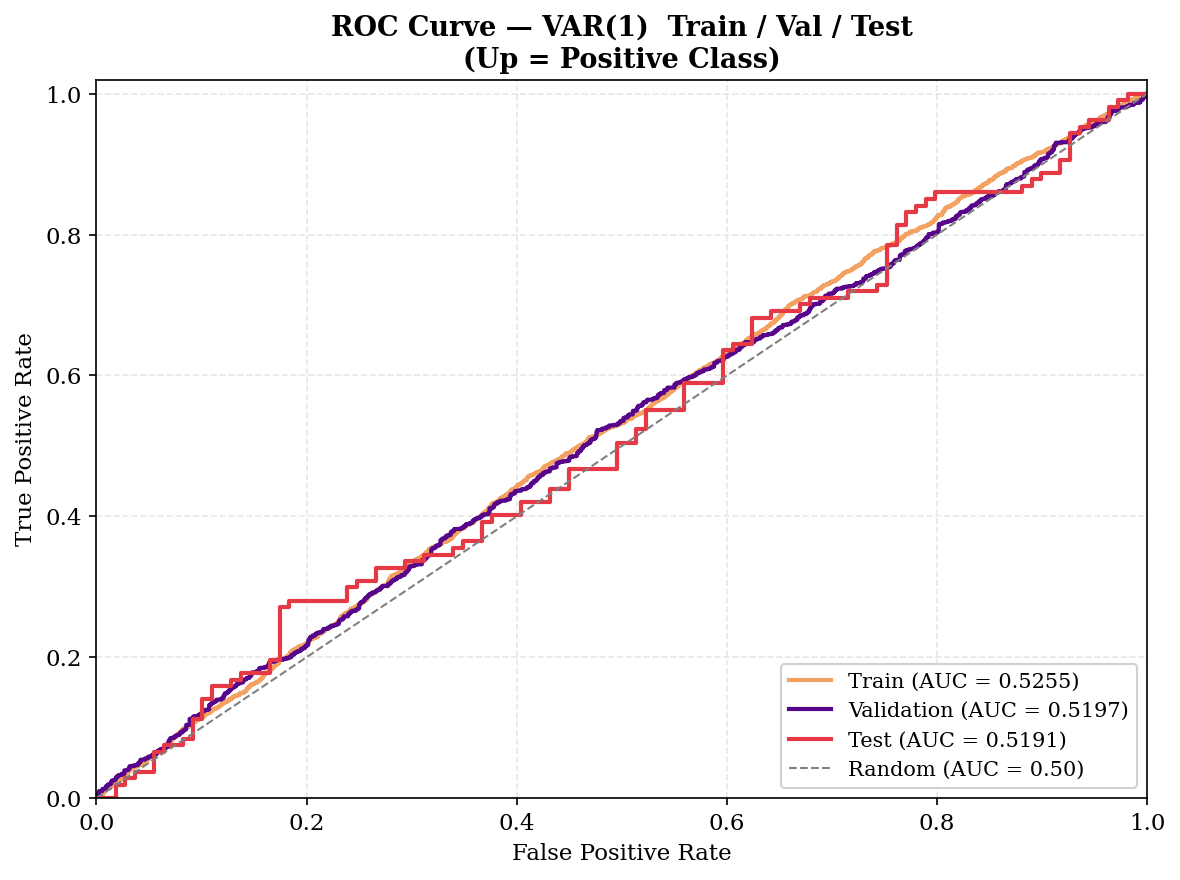

Split             AUC    Accuracy
───────────────────────────────────
Train          0.5255      0.5197
Validation     0.5197      0.5104
Test           0.5191      0.4954


In [93]:
# ============================================================
# ROC Curves — Train, Validation, and Test
# ============================================================
from sklearn.metrics import roc_curve

# Training-set probabilities from stored rolling forecasts
# train_forecasts_ starts from row p, so align y_train accordingly
p            = model.best_p_
fc_train_raw = model.train_forecasts_                         # shape (T_train - p,)
prob_train   = norm.cdf((fc_train_raw - model.threshold_) / model.sigma_)
y_train_trim = y_train.values[p:]                             # aligned labels

splits = [
    ("Train",      y_train_trim,  prob_train, "#f4a261"),
    ("Validation", y_val.values,  prob_val,   C_PALETTE['model']),
    ("Test",       y_test.values, prob_test,  C_PALETTE['accent']),
]

fig, ax = plt.subplots(figsize=(8, 6))
for label, y_true, y_prob, color in splits:
    fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=1)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], color="gray", lw=1, ls="--", label="Random (AUC = 0.50)")
ax.set_title(f"ROC Curve — VAR({model.best_p_})  Train / Val / Test\n(Up = Positive Class)",
             fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.legend(loc="lower right", framealpha=0.9)
plt.tight_layout()
plt.show()

# AUC summary
print(f"{'Split':<12} {'AUC':>8}  {'Accuracy':>10}")
print("─" * 35)
for label, y_true, y_prob, _ in splits:
    pred = np.where(y_prob >= 0.5, 1, -1)
    print(f"{label:<12} {roc_auc_score(y_true, y_prob):>8.4f}  "
          f"{accuracy_score(y_true, pred):>10.4f}")

## 19. Save Model

In [94]:
# ============================================================
# Save trained model to disk
# ============================================================
model.save("var_wti_direction.pkl")
print("Model saved to var_wti_direction.pkl")

Model saved to var_wti_direction.pkl
